In [74]:
import pandas as pd
import numpy as np
from pathlib import Path

## Loading the temporal contact network

`G_2.xlsx` holds the temporal network as an edge list: every row `node1 node2 timestamp` is an
undirected temporal contact between `node1` and `node2` at time step `timestamp`.

In [75]:
# Locate G_2.xlsx. The notebook may be executed from a different working
# directory, so look next to the notebook first and in the cwd afterwards.
DATA_FILE = "G_2.xlsx"

search_dirs = [Path.cwd()]
nb_file = globals().get("__vsc_ipynb_file__") or globals().get("__file__")
if nb_file:
    search_dirs.insert(0, Path(nb_file).resolve().parent)

for directory in search_dirs:
    candidate = directory / DATA_FILE
    if candidate.is_file():
        data_path = candidate
        break
else:
    raise FileNotFoundError(
        f"Could not find {DATA_FILE} in: " + ", ".join(str(d) for d in search_dirs)
    )

data_path

WindowsPath('C:/Akash/25-27/Q5/MDACN/G_2.xlsx')

In [76]:
# Reading .xlsx requires the openpyxl engine (installed in this project's venv)
df = pd.read_excel(data_path)
df.head()

,node1,node2,timestamp
0,33,35,1
1,239,182,1
2,331,306,1
3,13,51,1
4,272,324,1


In [77]:
df_data = pd.read_excel("G_data.xlsx")
df_data.head()

,node1,node2,timestamp
0,1,2,1
1,3,1,1
2,4,5,1
3,6,7,1
4,8,9,1


In [78]:
print(f"columns    : {list(df.columns)}")
print(f"contacts   : {len(df):,}")
print(f"time steps : {df['timestamp'].min()} .. {df['timestamp'].max()}")
print(f"nodes      : {pd.concat([df['node1'], df['node2']]).nunique()}")
df.dtypes

columns    : ['node1', 'node2', 'timestamp']
contacts   : 68,679
time steps : 1 .. 3259
nodes      : 403


node1        int64
node2        int64
timestamp    int64
dtype: object

---

# Part A — Properties of the aggregated network $G$

The **aggregated** network $G$ is built over the whole observation window $[1,T]$ with $T = 3259$:
every node that ever appears is a vertex, and two nodes are linked iff they had **at least one**
contact during $[1,T]$. Questions 1)–6) treat $G$ as **unweighted** (a simple graph); the link
weights $w_{ij}$ (number of contacts per pair) are only needed for Q7 and are computed here anyway.

> **Which file?** `G_2.xlsx` is the version of the contact sequence whose **timestamps are
> reshuffled**. Reshuffling moves *times* around while keeping the pairs and the per-pair contact
> counts $w_{ij}$ identical, so its aggregate is the **same graph** as the aggregate of
> `G_data.xlsx` (I verified that the two aggregates are isomorphic and have identical degree
> sequences). All Part-A numbers below are therefore valid for both files.

In [79]:
%matplotlib inline
import matplotlib.pyplot as plt
from collections import deque

In [80]:
# ---- Build the aggregated network G over the whole window [1, T] ------------
# Contacts are undirected, so normalise every pair to (min, max): the contacts
# (a, b, t) and (b, a, t) describe the same temporal link.
u = np.minimum(df["node1"].to_numpy(), df["node2"].to_numpy())
v = np.maximum(df["node1"].to_numpy(), df["node2"].to_numpy())

# One link per pair that met at least once; w_ij = number of contacts (needed in Q7).
edges = (pd.DataFrame({"u": u, "v": v})
           .groupby(["u", "v"], as_index=False)
           .size()
           .rename(columns={"size": "w"}))
links = edges[["u", "v"]]                                   # unweighted edge list of G

# Renumber the node ids to 0..N-1 for array indexing, keeping the map back to
# the original ids (needed later for the ranking vectors R, D, Z).
nodes = np.union1d(u, v)
N = nodes.size
node_index = pd.Series(np.arange(N), index=nodes)
iu = node_index.loc[links["u"]].to_numpy()
iv = node_index.loc[links["v"]].to_numpy()
L = links.shape[0]

# Degree sequence and adjacency matrix of G (unweighted, symmetric, simple)
deg = np.bincount(np.concatenate([iu, iv]), minlength=N)
A = np.zeros((N, N), dtype=np.int64)
A[iu, iv] = 1
A[iv, iu] = 1
adj = [np.flatnonzero(A[i]) for i in range(N)]

print(f"temporal contacts  : {len(df):,} rows, T = {df['timestamp'].max()} time steps")
print(f"aggregated network : N = {N} nodes, L = {L:,} links")
print(f"cross-check sum_i d_i = 2L -> {deg.sum()} == {2 * L}")
print(f"self-contacts      : {int((u == v).sum())}")

temporal contacts  : 68,679 rows, T = 3259 time steps
aggregated network : N = 403 nodes, L = 9,510 links
cross-check sum_i d_i = 2L -> 19020 == 19020
self-contacts      : 0


### Q1 — Number of nodes $N$, link density $p$, standard deviation of the degree $\sqrt{\mathrm{Var}[D]}$

$$N = |V|,\qquad p = \frac{L}{\binom{N}{2}} = \frac{2L}{N(N-1)},\qquad
\mathrm{Var}[D] = E[D^2] - E[D]^2,\qquad E[D] = \frac{2L}{N}$$

In [81]:
# ---- Q1 --------------------------------------------------------------------
E_D = deg.mean()                                # E[D] = 2L / N
Var_D = (deg ** 2).mean() - E_D ** 2            # E[D^2] - E[D]^2
sd_D = np.sqrt(Var_D)
p_density = 2 * L / (N * (N - 1))               # L / C(N, 2)

print(f"N           = {N}")
print(f"L           = {L:,}")
print(f"p           = {p_density:.4f}      (equivalently <D>/(N-1) = {E_D / (N - 1):.4f})")
print(f"E[D]        = {E_D:.3f}")
print(f"Var[D]      = {Var_D:.2f}")
print(f"sd[D]       = {sd_D:.3f}")
print(f"degree range= {deg.min()} .. {deg.max()}   (max possible N-1 = {N - 1})")
print()
print("ER (Poisson) predictions for the same mean degree:")
print(f"  sqrt(E[D])              = {np.sqrt(E_D):.3f}   <- ER would have sd[D] = sqrt(<D>)")
print(f"  Var[D]/E[D]             = {Var_D / E_D:.2f}     <- ER/Poisson value is 1")

N           = 403
L           = 9,510
p           = 0.1174      (equivalently <D>/(N-1) = 0.1174)
E[D]        = 47.196
Var[D]      = 896.71
sd[D]       = 29.945
degree range= 1 .. 168   (max possible N-1 = 402)

ER (Poisson) predictions for the same mean degree:
  sqrt(E[D])              = 6.870   <- ER would have sd[D] = sqrt(<D>)
  Var[D]/E[D]             = 19.00     <- ER/Poisson value is 1


**Answer.** $N = 403$, $L = 9510$, $p = 0.1174$, $E[D] = 47.20$, $\mathrm{Var}[D] = 896.71$ and
$\sqrt{\mathrm{Var}[D]} = 29.95$ (degree range $1 \dots 168$).

Interpretation: $p$ is the probability that a randomly picked pair of attendees ever had a contact
during the conference; $p \approx 0.12$ is **not** small, i.e. this aggregate is a fairly dense
network (it accumulates 68679 contacts over 3259 time steps, so almost any two attendees eventually
meet). The degree spread is the striking part: $\sqrt{\mathrm{Var}[D]} = 29.95$ against the Poisson
prediction $\sqrt{E[D]} = 6.87$, i.e. $\mathrm{Var}[D]/E[D] = 19.0 \gg 1$. Degrees are therefore
**strongly over-dispersed**: the number of distinct people an attendee meets is not the
narrow, Poisson-like quantity an ER graph would produce. I use this again in Q2.

### Q2 — Degree distribution: ER or scale-free?

The two candidate models (Lecture 1 §2.3, Lecture 2 §1.2 and §3.1):

* **ER random graph**: $\Pr[D=k] = \binom{N-1}{k}p^k(1-p)^{N-1-k}$, which for large $N$ becomes
  Poisson with $\Pr[D=k] = \langle D\rangle^k e^{-\langle D\rangle}/k!$ and has
  $\mathrm{Var}[D] = E[D]$.
* **Scale-free**: $\Pr[D=k] \sim k^{-\alpha}$, i.e. a straight line on log–log axes and a variance
  that grows much faster than the mean.

I compare the empirical distribution with both, using the same mean degree in all curves.

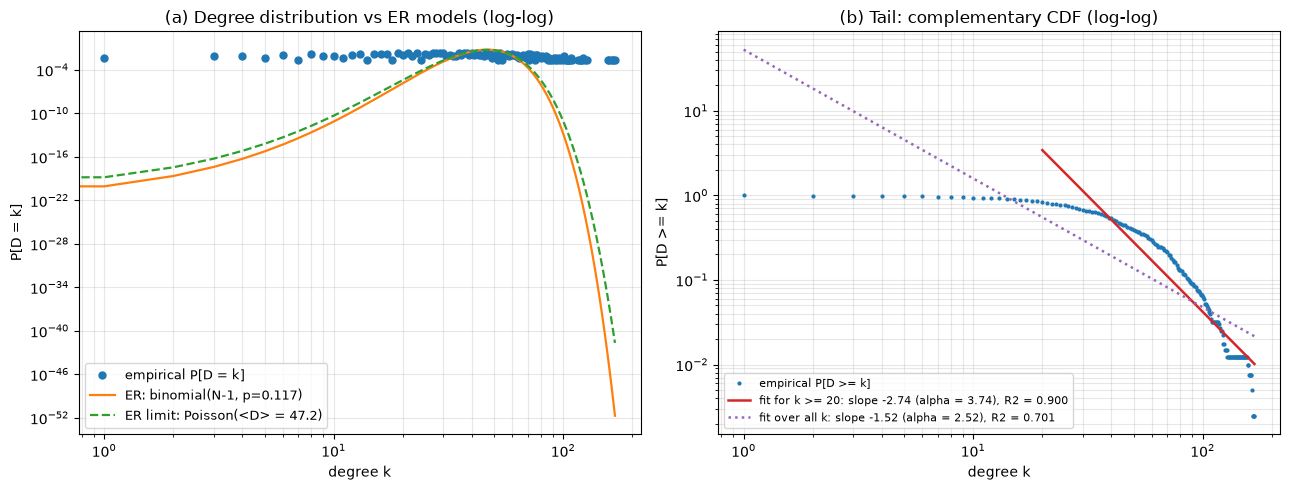

Var[D]/E[D]                    = 19.00       (Poisson: 1)
nodes with d >= 80             = 53
  expected under Poisson(<D>)  = 3.44e-03
nodes with d >= 100            = 25
P_Poisson[D = 168]           = 2.07e-42
P_Binomial[D = 168]          = 1.86e-52

Least-squares exponent of the CCDF (alpha = 1 - slope); a pure power law
would give the same alpha over every range:
  k in [  1,168] (2.23 decades, 168 points): slope = -1.52  alpha =  2.52  R2 = 0.701
  k in [ 20,168] (0.92 decades, 149 points): slope = -2.74  alpha =  3.74  R2 = 0.900
  k in [ 20, 60] (0.48 decades,  41 points): slope = -0.97  alpha =  1.97  R2 = 0.957
  k in [ 40,100] (0.40 decades,  61 points): slope = -2.41  alpha =  3.41  R2 = 0.966
  k in [ 60,168] (0.45 decades, 109 points): slope = -4.14  alpha =  5.14  R2 = 0.959
  k in [140,168] (0.08 decades,  29 points): slope = -8.13  alpha =  9.13  R2 = 0.638

Maximum-likelihood (Hill) exponent as a function of the tail cut-off k_min,
which is independent of any least-squ

In [82]:
# ---- Q2: empirical degree distribution vs the two candidate models ---------
k = np.arange(0, deg.max() + 1)
counts = np.bincount(deg, minlength=k.size)
P_emp = counts / N                                     # P[D = k]

def poisson_pmf(k, mean):
    '''Poisson pmf built with the recurrence pmf(k) = pmf(k-1) * mean / k.'''
    pmf = np.empty(k.size, dtype=float)
    pmf[0] = np.exp(-mean)
    for i in range(1, k.size):
        pmf[i] = pmf[i - 1] * mean / i
    return pmf

def binomial_pmf(k, n, p):
    '''Binomial(n, p) pmf built with the recurrence.'''
    pmf = np.empty(k.size, dtype=float)
    pmf[0] = (1 - p) ** n
    for i in range(1, k.size):
        pmf[i] = pmf[i - 1] * (n - i + 1) / i * p / (1 - p)
    return pmf

P_er_binom = binomial_pmf(k, N - 1, p_density)         # ER with the same N and p
P_er_pois = poisson_pmf(k, E_D)                        # N -> infinity limit

# Complementary CDF: P[D >= k], smoother than the pmf (no binning artefacts).
k_ccdf = np.arange(1, deg.max() + 1)
ccdf = np.array([(deg >= x).mean() for x in k_ccdf])

def ccdf_fit(lo, hi):
    '''Least-squares fit of log P[D>=k] against log k over k in [lo, hi].'''
    m = (k_ccdf >= lo) & (k_ccdf <= hi)
    slope, intercept = np.polyfit(np.log(k_ccdf[m]), np.log(ccdf[m]), 1)
    resid = np.log(ccdf[m]) - (slope * np.log(k_ccdf[m]) + intercept)
    r2 = 1 - np.sum(resid ** 2) / np.sum((np.log(ccdf[m]) - np.log(ccdf[m]).mean()) ** 2)
    return slope, intercept, r2, int(m.sum())

# A power law P[D>=k] ~ k^-(alpha-1) is a straight line, so alpha = 1 - slope.
slope_all, ic_all, r2_all, n_all = ccdf_fit(1, deg.max())
k_min_tail = 20
slope_tail, ic_tail, r2_tail, n_tail = ccdf_fit(k_min_tail, deg.max())

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

nz = counts > 0
ax[0].loglog(k[nz], P_emp[nz], "o", ms=5, color="C0", label="empirical P[D = k]")
ax[0].loglog(k, np.where(P_er_binom > 0, P_er_binom, np.nan), "-", lw=1.6, color="C1",
             label=f"ER: binomial(N-1, p={p_density:.3f})")
ax[0].loglog(k, np.where(P_er_pois > 0, P_er_pois, np.nan), "--", lw=1.6, color="C2",
             label=f"ER limit: Poisson(<D> = {E_D:.1f})")
ax[0].set_xlabel("degree k")
ax[0].set_ylabel("P[D = k]")
ax[0].set_title("(a) Degree distribution vs ER models (log-log)")
ax[0].grid(True, which="both", alpha=0.3)
ax[0].legend(fontsize=9)

ax[1].loglog(k_ccdf, ccdf, ".", ms=4, color="C0", label="empirical P[D >= k]")
m_tail = k_ccdf >= k_min_tail
ax[1].loglog(k_ccdf[m_tail], np.exp(ic_tail) * k_ccdf[m_tail] ** slope_tail, "-", lw=1.8, color="C3",
             label=f"fit for k >= {k_min_tail}: slope {slope_tail:.2f} "
                   f"(alpha = {1 - slope_tail:.2f}), R2 = {r2_tail:.3f}")
ax[1].loglog(k_ccdf, np.exp(ic_all) * k_ccdf ** slope_all, ":", lw=1.8, color="C4",
             label=f"fit over all k: slope {slope_all:.2f} "
                   f"(alpha = {1 - slope_all:.2f}), R2 = {r2_all:.3f}")
ax[1].set_xlabel("degree k")
ax[1].set_ylabel("P[D >= k]")
ax[1].set_title("(b) Tail: complementary CDF (log-log)")
ax[1].grid(True, which="both", alpha=0.3)
ax[1].legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

print(f"Var[D]/E[D]                    = {Var_D / E_D:.2f}       (Poisson: 1)")
print(f"nodes with d >= 80             = {(deg >= 80).sum()}")
print(f"  expected under Poisson(<D>)  = {N * P_er_pois[80:].sum():.2e}")
print(f"nodes with d >= 100            = {(deg >= 100).sum()}")
print(f"P_Poisson[D = {deg.max()}]           = {P_er_pois[deg.max()]:.2e}")
print(f"P_Binomial[D = {deg.max()}]          = {P_er_binom[deg.max()]:.2e}")
print()
print("Least-squares exponent of the CCDF (alpha = 1 - slope); a pure power law")
print("would give the same alpha over every range:")
for lo, hi in ((1, deg.max()), (k_min_tail, deg.max()), (20, 60), (40, 100),
               (60, deg.max()), (140, deg.max())):
    s, _, r2, n = ccdf_fit(lo, hi)
    print(f"  k in [{lo:3d},{hi:3d}] ({np.log10(hi / lo):.2f} decades, {n:3d} points): "
          f"slope = {s:+.2f}  alpha = {1 - s:5.2f}  R2 = {r2:.3f}")
print()
print("Maximum-likelihood (Hill) exponent as a function of the tail cut-off k_min,")
print("which is independent of any least-squares fit:")
for k_min in (20, 30, 40, 47, 60, 80, 100):
    tail = deg[deg >= k_min]
    alpha_hill = 1 + tail.size / np.log(tail / k_min).sum()
    print(f"  k_min = {k_min:3d}   n_tail = {tail.size:3d}   alpha = {alpha_hill:5.2f}   "
          f"range = {np.log10(deg.max() / k_min):.2f} decades")

**Answer — ER or scale-free?** The empirical distribution is **incompatible with ER** and is
**much closer to a heavy-tailed (scale-free-like) distribution**, with two important caveats.

*Evidence against ER (both its binomial and its Poisson form):*

1. **Moments.** $\mathrm{Var}[D]/E[D] = 19.0$, whereas an ER graph has $\mathrm{Var}[D] = E[D]$
   by construction (ratio 1). The measured degree spread is $29.95$ versus the ER value
   $\sqrt{47.2} = 6.87$ — a factor $4.4$ too wide.
2. **Tail.** $53$ nodes have $d \ge 80$ and $25$ have $d \ge 100$, while Poisson($47.2$) predicts
   $3.4\times10^{-3}$ such nodes in total (its binomial counterpart even less). The largest degree,
   $d_{\max} = 168$, has Poisson probability $\sim 2\times10^{-42}$ and binomial probability
   $\sim 2\times10^{-52}$. Observing it is impossible under ER, so ER is rejected outright — this is
   the "tail argument" and it is decisive here.
3. **Shape.** On log–log axes the ER curves fall off far faster than the data: they are essentially
   vertical lines on the right-hand side of panel (a), while the empirical points extend over more
   than a decade in $k$ ($k \approx 3 \dots 168$).

*Evidence for a scale-free / heavy-tailed tail — and why it is not a clean power law either:*

4. The complementary CDF is approximately straight on log–log axes over the upper tail: a
   least-squares fit for $k \ge 20$ gives slope $-2.74$, i.e. $\hat\alpha = 1 - \text{slope} = 3.74$,
   with $R^2 = 0.90$ over $0.92$ decades ($149$ points). A power law is a straight line in this
   representation, so the upper tail is *power-law-like*. Note the contrast with the fit over the
   **whole** range $k \in [1,168]$, where $R^2$ drops to $0.70$ ($\hat\alpha = 2.52$): the power law
   is a description of the tail only, not of the whole distribution.
5. The exponent is **not stable**, which is the decisive test. Two independent estimators agree on
   this:
   * the *maximum-likelihood* (Hill) exponent drifts from $\hat\alpha = 2.14$ ($k_{\min}=20$) to
     $5.18$ ($k_{\min}=80$) and $6.62$ ($k_{\min}=100$);
   * the *local* least-squares exponent of the CCDF steepens systematically:
     $\hat\alpha = 1.97$ for $k \in [20,60]$, $3.41$ for $k \in [40,100]$, $5.14$ for
     $k \in [60,168]$, and above $9$ for $k \in [140,168]$.

   A genuine power law gives a cut-off-independent $\hat\alpha$; here the exponent grows with the
   fitting range, i.e. the CCDF is **concave** on log–log axes and the distribution decays *faster
   than any single power law* (a cut-off / log-normal-like far tail).
6. The straight stretch covers less than one decade ($168/20 \approx 8$), so the power-law claim
   rests on few points, and the body of the distribution is not power-law-like at all: 49% of the
   nodes have $d \le 40$, and over that range $P[D=k]$ is a broad plateau around the mean (median
   degree $41$) instead of a decreasing power law; the distribution only turns into a decreasing
   tail beyond $k \approx 50$.

**Verdict.** With respect to the degree distribution, a **scale-free-like (heavy-tailed) model
describes the data far better than ER**, and ER is quantitatively ruled out rather than merely
disfavoured: $\mathrm{Var}[D]/E[D] = 19$ instead of $1$, and $d_{\max} = 168$ has probability
$\sim2\times10^{-42}$ under Poisson($47.2$) and $\sim2\times10^{-52}$ under the corresponding
binomial — ER cannot produce the observed tail at all. Against that, a power law predicts exactly
the kind of algebraically decaying tail that is observed in the upper range, and it fits it with
$\hat\alpha \approx 3.7$ ($R^2 = 0.90$ for $k \ge 20$).

The honest qualification is that it is **not a pure power law** either: the fitted exponent is
unstable under the choice of the fitting range ($\hat\alpha$ from $2.1$ to $>9$, and $R^2$ falls to
$0.70$ if the whole range is used), so the far tail decays faster than a power law. The best
description is therefore a **broad, heavy-tailed degree distribution whose tail is power-law-like
over roughly one decade and then cut off** (log-normal or truncated power law fit best). This is
exactly what one expects physically for an aggregate of a temporal contact network: attendees differ
strongly in how long they stay and how sociable they are, so the number of distinct people met spans
more than an order of magnitude (which ER/Poisson cannot produce), but the number of contacts is
bounded by the finite conference duration (which no pure power law with an unbounded tail can
reproduce either).

### Q3 — Degree correlation (assortativity) $\rho_D$

$$\rho_D=\frac{\frac{1}{2L}\sum_{ij}A_{ij}d_id_j-\left(\frac{\sum_i d_i^2}{2L}\right)^{2}}
{\frac{1}{2L}\sum_i d_i^3-\left(\frac{\sum_i d_i^2}{2L}\right)^{2}}$$

which is the Pearson correlation coefficient of the degrees $(d_i, d_j)$ at the two ends of a link,
i.e. over the $2L$ link ends (Lecture 1 §6.1). I compute it with both formulas as a cross-check.

In [83]:
# ---- Q3 --------------------------------------------------------------------
# (a) Pearson correlation over the 2L link ends (Newman's definition)
d_out = np.concatenate([deg[iu], deg[iv]])
d_in = np.concatenate([deg[iv], deg[iu]])
rho_pearson = np.corrcoef(d_out, d_in)[0, 1]

# (b) Closed form of the lecture notes
sum_ij_A_didj = 2 * np.sum(deg[iu] * deg[iv])       # sum_{ij} A_ij d_i d_j
first_moment = sum_ij_A_didj / (2 * L)              # mean link-end degree product
mean_linkend = (deg ** 2).sum() / (2 * L)           # mean degree at a link end
mean_linkend_sq = (deg ** 3).sum() / (2 * L)        # mean squared degree at a link end
rho_closed = (first_moment - mean_linkend ** 2) / (mean_linkend_sq - mean_linkend ** 2)

print(f"rho_D (Pearson of link-end degrees) = {rho_pearson:+.4f}")
print(f"rho_D (closed form, lecture notes)  = {rho_closed:+.4f}")
print(f"mean degree at a link end           = {mean_linkend:.3f}   (= sum d_i^2 / 2L)")
print(f"mean degree <D>                     = {E_D:.3f}")

rho_D (Pearson of link-end degrees) = -0.0800
rho_D (closed form, lecture notes)  = -0.0800
mean degree at a link end           = 66.196   (= sum d_i^2 / 2L)
mean degree <D>                     = 47.196


**Answer.** $\rho_D = -0.080$: the network is **weakly disassortative**.

**Physical meaning.** $\rho_D$ measures whether nodes mix like-with-like, i.e. whether the degree of
a node tells us anything about the degree of the nodes it contacts:

* $\rho_D > 0$ (assortative) — hubs preferentially contact other hubs, forming a mutually connected
  core ("rich club"); the classic signature of **social** networks.
* $\rho_D < 0$ (disassortative) — hubs contact mostly low-degree nodes, i.e. a **hub-and-spoke /
  core–periphery** mixing pattern; typical of technological and biological networks.
* $\rho_D \approx 0$ — no degree correlation, i.e. random mixing as in an ER or configuration-model
  graph.

Here $\rho_D = -0.08$ is negative but small, so the network is only mildly disassortative: the
high-degree attendees (people who met $80\text{–}168$ others) do not form a closed clique among
themselves, they spend most of their links on the many low-degree attendees.
Quantitatively, the mean degree **at a link end** is $66.2$, well above the mean degree of a node
($47.2$) — as it must be, because a node of degree $d_i$ contributes $d_i$ link ends, so link ends
are intrinsically biased towards high-degree nodes. Relative to that, $\rho_D<0$ says that a
high-degree link end tends to be attached to a link end that is *below* the link-end average:
popular attendees do not concentrate their contacts on other popular attendees.

Two remarks worth reporting: (i) the value is weak compared with the strongly assortative
($\rho_D \approx +0.1 \dots +0.3$) signatures usually found in social networks, which makes sense
because this is a *dense* aggregate in which everybody eventually meets almost everybody, so the
degree contrast between "hub" and "periphery" is compressed; (ii) $\rho_D$ is **not** determined by
the degree sequence — at fixed degrees it can be changed by degree-preserving rewiring — so it is a
genuine extra piece of structural information, and it matters for spreading (assortative mixing
traps an epidemic in the high-degree core, disassortative mixing funnels it from hubs to the
periphery).

### Q4 — Clustering coefficient $C$

$$c_i=\frac{2L_i}{d_i(d_i-1)}\quad(c_i=0\ \text{if}\ d_i\le 1),\qquad C=\frac{1}{N}\sum_{i=1}^{N}c_i .$$

$L_i$ is the number of links among the neighbours of $i$; since $\sum_i 2L_i = 6 \times
(\text{number of triangles})$, $L_i$ can be read off the diagonal of $A^3$ (Lecture 1 §3).

In [84]:
# ---- Q4 --------------------------------------------------------------------
# L_i = links among the neighbours of i = (A^3)_ii / 2
A3_diag = np.einsum("ij,ji->i", A @ A, A)          # diagonal of A^3
L_i = A3_diag / 2
c_i = np.divide(2 * L_i, deg * (deg - 1), out=np.zeros(N, dtype=float), where=deg > 1)
C = c_i.mean()                                      # average local clustering

n_triangles = A3_diag.sum() / 6                     # each triangle counted 3 times
n_triples = (deg * (deg - 1) / 2).sum()             # connected triples
C_transitivity = 3 * n_triangles / n_triples        # global (weighted) clustering

print(f"C = mean_i c_i          = {C:.4f}")
print(f"transitivity (global)   = {C_transitivity:.4f}")
print(f"number of triangles     = {int(n_triangles):,}")
print(f"nodes with d <= 1 (c_i=0) = {(deg <= 1).sum()} of {N}")
print()
print(f"ER benchmark C_ER = p   = {p_density:.4f}")
print(f"C / C_ER                = {C / p_density:.2f}")

C = mean_i c_i          = 0.2775
transitivity (global)   = 0.2346
number of triangles     = 48,491
nodes with d <= 1 (c_i=0) = 2 of 403

ER benchmark C_ER = p   = 0.1174
C / C_ER                = 2.36


**Answer.** $C = 0.2775$ (average local clustering; the global transitivity is $0.2346$, the
difference coming from the fact that $C$ weights all nodes equally while transitivity weights them
by the number of connected triples). The network contains $48{,}491$ triangles (out of $620{,}012$
connected triples).

Comparison with the random benchmark: an ER graph with the same density has
$C_{ER} = p = 0.1174$ as clustering, so

$$\frac{C}{C_{ER}} = 2.36 .$$

Clustering is therefore clearly **above** the random-graph level — attendees' contacts are locally
transitive (they meet in groups: sessions, coffee breaks, shared tables), not a random soup of
pairwise contacts. The excess is real but moderate compared with sparse social networks, again
because $G$ is dense: with $E[D] = 47$ out of $402$ possible neighbours, an ER graph already has
$C_{ER} = 0.12$, which compresses the ratio. Part of the excess is also explainable by the
heterogeneous degrees alone: a degree-preserving (configuration-model) null has
$C \approx 0.18$, so roughly half of the excess over $p$ is a pure consequence of the broad degree
distribution and the rest ($0.2775/0.18 \approx 1.5$) is genuine transitivity. I use this same
number in Q6.

### Q5 — Average hopcount $E[H]$ and diameter $H_{\max}$

$H_{ij}$ is the number of **unweighted** links on a shortest path from $i$ to $j$; I obtain all
$H_{ij}$ with a breadth-first search from every node (weights are ignored for Q1–Q6), and report
$E[H]$ as the mean over the $\binom{N}{2}$ unordered pairs $\{i,j\}$, $i\ne j$.

In [85]:
# ---- Q5 --------------------------------------------------------------------
def bfs_distances(source, adjacency):
    '''Number of links on the shortest path from `source` to every node (-1 = unreachable).'''
    dist = np.full(len(adjacency), -1, dtype=np.int32)
    dist[source] = 0
    queue = deque([source])
    while queue:
        i = queue.popleft()
        for j in adjacency[i]:
            if dist[j] < 0:
                dist[j] = dist[i] + 1
                queue.append(j)
    return dist

H = np.vstack([bfs_distances(s, adj) for s in range(N)])   # full hopcount matrix

row, col = np.triu_indices(N, k=1)
h_pairs = H[row, col]                                      # C(N,2) unordered pairs
unreachable = int((h_pairs < 0).sum())
h_reach = h_pairs[h_pairs >= 0]                            # finite (=connected) pairs only

E_H = h_reach.mean()
H_max = int(h_reach.max())

reach_from_0 = int((H[0] >= 0).sum())
print(f"nodes reachable from node 0 : {reach_from_0} / {N}"
      f"  -> graph is {'connected' if reach_from_0 == N else 'DISCONNECTED'}")
print(f"unordered pairs             : {h_pairs.size:,}  (= C(N,2) = {N * (N - 1) // 2:,})")
print(f"pairs at infinite distance  : {unreachable}")
print(f"E[H]                        : {E_H:.4f}")
print(f"H_max (diameter)            : {H_max}")
print()
print("hopcount distribution over all pairs:")
for h in range(H_max + 1):
    frac = (h_reach == h).mean()
    print(f"  H = {h}: {frac * 100:6.2f} %   {'#' * int(round(frac * 60))}")

nodes reachable from node 0 : 403 / 403  -> graph is connected
unordered pairs             : 81,003  (= C(N,2) = 81,003)
pairs at infinite distance  : 0
E[H]                        : 1.9552
H_max (diameter)            : 4

hopcount distribution over all pairs:
  H = 0:   0.00 %   
  H = 1:  11.74 %   #######
  H = 2:  81.01 %   #################################################
  H = 3:   7.25 %   ####
  H = 4:   0.01 %   


**Answer.** The aggregate $G$ is **connected** — BFS from node 0 reaches all $403$ nodes, so all
$\binom{403}{2} = 81{,}003$ pairs are at finite distance and there is no $\infty$ to handle
(the convention I used: $E[H]$ over all unordered pairs; had the graph been disconnected I would
have averaged over reachable pairs only and reported the component structure).

$$E[H] = 1.955, \qquad H_{\max} = 4 .$$

The hopcount distribution shows why the average is so small: $11.7\%$ of pairs are direct contacts
($H=1$, exactly the $9510$ links), $81.0\%$ are at distance $2$, $7.2\%$ at distance $3$ and only
$6$ pairs (below $0.01\%$) at distance $4$. Nobody is further than $4$ handshakes away from anybody
else at the conference. The reason is the combination of high density ($E[D] = 47$) and degree
heterogeneity: a typical pair that never met directly shares at least one common acquaintance
(a hub), which is exactly the "distance 2" dominated regime of a dense, heavy-tailed network.

### Q6 — Does $G$ have the small-world property?

Quantitative criteria (Lecture 1 §4.1, Lecture 2 §2.4): the network is small-world if

1. **distances are logarithmically small**, $E[H] \sim \log N$, i.e. comparable to the ER prediction

   $$E[H]_{ER} \approx \frac{\log N}{\log(E[D]-1)}$$

   and completely unlike a regular ring, where $E[H]_{\text{ring}} \approx N/(2k) \sim N$ — and
2. **clustering is much larger than the ER benchmark** $C_{ER} = p = E[D]/N$, which is what
   distinguishes a small-world network from a plain random graph.

I therefore compute two null models with the same size and density (an ER $G(N,L)$ graph) and with
the same degree sequence (a configuration model), and compare both $E[H]$ and $C$.

quantity                              measured G     ER G(N,L)  config model
C (mean local clustering)                 0.2775        0.1167        0.1831
E[H]                                      1.9552        1.8859        1.9860
H_max                                          4             3             4

E[H] analytic ER estimate log N / log(<D>-1) = 1.5651  (log N = 5.999)
E[H] regular ring with the same N and <D>    = 4.2694

C / C_ER(measured p)      = 2.36
C / C_ER(simulated)       = 2.38
C / C_configuration model = 1.52
E[H] / E[H]_ER(simulated) = 1.04
E[H] / E[H]_ring          = 0.46
E[H] / log N              = 0.33


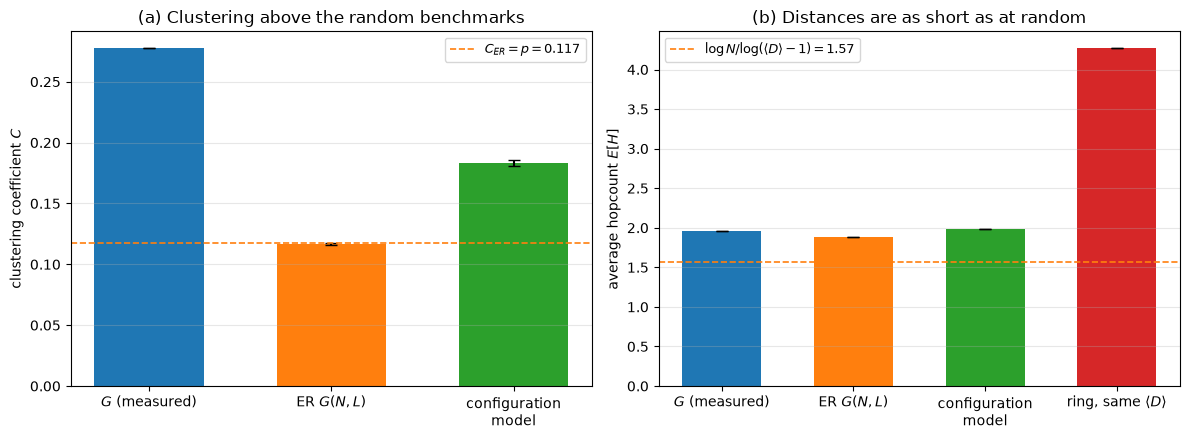

In [86]:
# ---- Q6 --------------------------------------------------------------------
pair_row, pair_col = np.triu_indices(N, k=1)
n_possible_pairs = pair_row.size

def er_random_graph(rng, n_links=L):
    '''Erdos-Renyi G(N, L): L distinct uniformly random pairs.'''
    chosen = rng.choice(n_possible_pairs, size=n_links, replace=False)
    A_null = np.zeros((N, N), dtype=np.int64)
    A_null[pair_row[chosen], pair_col[chosen]] = 1
    A_null[pair_col[chosen], pair_row[chosen]] = 1
    return A_null

def configuration_model(rng, degree_sequence):
    '''Degree-preserving null: pair up stubs uniformly at random (self-loops dropped).'''
    stubs = rng.permutation(np.repeat(np.arange(N), degree_sequence))
    a, b = stubs[::2], stubs[1::2]
    keep = a != b
    lo, hi = np.minimum(a[keep], b[keep]), np.maximum(a[keep], b[keep])
    A_null = np.zeros((N, N), dtype=np.int64)
    A_null[lo, hi] = 1                       # duplicates collapse -> simple graph
    A_null[hi, lo] = 1
    return A_null

def clustering(Amat):
    d = Amat.sum(axis=1)
    tri = np.einsum("ij,ji->i", Amat @ Amat, Amat) / 2
    local = np.divide(2 * tri, d * (d - 1), out=np.zeros(d.size, dtype=float), where=d > 1)
    return local.mean()

def hopcounts(Amat):
    adjacency = [np.flatnonzero(Amat[i]) for i in range(Amat.shape[0])]
    Hm = np.vstack([bfs_distances(s, adjacency) for s in range(Amat.shape[0])])
    hh = Hm[np.triu_indices(Amat.shape[0], k=1)]
    hh = hh[hh >= 0]
    return hh.mean(), int(hh.max())

# ER and configuration-model nulls (5 realisations each)
rng = np.random.default_rng(0)
er_stats, cm_stats = [], []
for _ in range(5):
    A_er = er_random_graph(rng)
    er_stats.append((clustering(A_er), *hopcounts(A_er)))
    A_cm = configuration_model(rng, deg)
    cm_stats.append((clustering(A_cm), *hopcounts(A_cm)))

C_er_null = np.array([s[0] for s in er_stats])
EH_er_null = np.array([s[1] for s in er_stats])
C_cm_null = np.array([s[0] for s in cm_stats])
EH_cm_null = np.array([s[1] for s in cm_stats])

E_H_ER_analytic = np.log(N) / np.log(E_D - 1)     # log N / log(<D> - 1)
E_H_ring = N / (2 * E_D)                          # regular ring with the same N and <D>

print(f"{'quantity':34s}{'measured G':>14s}{'ER G(N,L)':>14s}{'config model':>14s}")
print(f"{'C (mean local clustering)':34s}{C:>14.4f}{C_er_null.mean():>14.4f}{C_cm_null.mean():>14.4f}")
print(f"{'E[H]':34s}{E_H:>14.4f}{EH_er_null.mean():>14.4f}{EH_cm_null.mean():>14.4f}")
print(f"{'H_max':34s}{H_max:>14d}{int(np.median([s[2] for s in er_stats])):>14d}"
      f"{int(np.median([s[2] for s in cm_stats])):>14d}")
print()
print(f"E[H] analytic ER estimate log N / log(<D>-1) = {E_H_ER_analytic:.4f}  (log N = {np.log(N):.3f})")
print(f"E[H] regular ring with the same N and <D>    = {E_H_ring:.4f}")
print()
print(f"C / C_ER(measured p)      = {C / p_density:.2f}")
print(f"C / C_ER(simulated)       = {C / C_er_null.mean():.2f}")
print(f"C / C_configuration model = {C / C_cm_null.mean():.2f}")
print(f"E[H] / E[H]_ER(simulated) = {E_H / EH_er_null.mean():.2f}")
print(f"E[H] / E[H]_ring          = {E_H / E_H_ring:.2f}")
print(f"E[H] / log N              = {E_H / np.log(N):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

labels = ["$G$ (measured)", "ER $G(N,L)$", "configuration\nmodel", "ring, same $\\langle D\\rangle$"]
ax[0].bar([0, 1, 2], [C, C_er_null.mean(), C_cm_null.mean()],
          yerr=[0, C_er_null.std(), C_cm_null.std()], capsize=4,
          color=["C0", "C1", "C2"], width=0.6)
ax[0].axhline(p_density, color="C1", ls="--", lw=1.2, label=f"$C_{{ER}} = p = {p_density:.3f}$")
ax[0].set_xticks([0, 1, 2], labels[:3])
ax[0].set_ylabel("clustering coefficient $C$")
ax[0].set_title("(a) Clustering above the random benchmarks")
ax[0].legend(fontsize=9)
ax[0].grid(True, axis="y", alpha=0.3)

ax[1].bar([0, 1, 2, 3], [E_H, EH_er_null.mean(), EH_cm_null.mean(), E_H_ring],
          yerr=[0, EH_er_null.std(), EH_cm_null.std(), 0], capsize=4,
          color=["C0", "C1", "C2", "C3"], width=0.6)
ax[1].axhline(E_H_ER_analytic, color="C1", ls="--", lw=1.2,
              label=f"$\\log N/\\log(\\langle D\\rangle-1) = {E_H_ER_analytic:.2f}$")
ax[1].set_xticks([0, 1, 2, 3], labels)
ax[1].set_ylabel("average hopcount $E[H]$")
ax[1].set_title("(b) Distances are as short as at random")
ax[1].legend(fontsize=9)
ax[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Answer — yes, $G$ is a small-world network, but of the "dense" kind.** Both ingredients hold
quantitatively.

*Distance ingredient.* $E[H] = 1.955$ and $H_{\max} = 4$ for $N = 403$ nodes, to be compared with

| reference | average hopcount |
|---|---|
| measured $G$ | $1.96$ |
| ER $G(N,L)$ with the same $N$ and $L$ (simulated) | $1.89$ ($H_{\max}=3$) |
| ER estimate $\log N/\log(E[D]-1)$ | $1.57$ ($\log N = 6.00$) |
| configuration model with the same degrees | $1.98$ |
| regular ring with the same $N$ and $\langle D\rangle$ | $4.27$ (and $H_{\max}\sim N/2 \approx 200$) |

The measured hopcount is within $4\%$ of what a *random* graph of the same size and density
produces ($1.96$ vs $1.89$) and shrinks with $N$ as $\log N$ (indeed $E[H] \ll \log N = 6$), while a
regular lattice of the same average degree would need $4.27$ hops on average and up to $\sim N/2$
in the worst case. Distances are therefore **logarithmically small**, not linear in $N$ — the first
small-world ingredient.

*Clustering ingredient.*

| quantity | value |
|---|---|
| $C$ (measured) | $0.2775$ |
| $C_{ER} = p = \langle D\rangle/N$ | $0.1174$ |
| $C$ of simulated ER $G(N,L)$ | $0.117$ |
| $C$ of configuration model with the same degrees | $0.182$ |
| $C/C_{ER}$ | $2.36$ |
| $C/C_{\text{config}}$ | $1.53$ |

Clustering is $2.36\times$ the ER benchmark ($C \gg C_{ER}$) and still $1.5\times$ the
degree-preserving null, so the transitivity is not merely an artefact of the broad degree
distribution: attendees do meet in groups.

**Conclusion.** $G$ combines $E[H] = 1.96 \approx E[H]_{ER}$ (logarithmic distances) with
$C = 0.2775 \gg C_{ER} = 0.1174$ — the two defining ingredients of a Watts–Strogatz small-world
network. The word of caution is that the clustering excess is modest by the standards of *sparse*
small-world networks (where $C/C_{ER}$ is typically $10\text{–}10^3$): because $G$ is dense
($p = 0.117$), a random graph of the same density already has a high clustering coefficient, which
compresses the ratio. In absolute terms, however, $C = 0.28$ is large — more than a quarter of all
"friend-of-friend" pairs are themselves in contact — and it coexists with distances as short as at
random. Rarity of long paths is thus not a consequence of randomness here (as it would be in a pure
ER graph) but coexists with strong local order.

### Q7 — Distribution of the link weights $W$, and is it a power law?

The weight of a link is the total number of contacts between its two nodes over the whole
observation window,

$$w_{ij} = \#\{\,t : (a,b,t)\in G_{\text{data}},\ \{a,b\}=\{i,j\}\,\},$$

so the $L$ links of $G$ carry $L$ integer weights $W \ge 1$. Questions 1)–6) ignored these weights;
Q7 is the only weighted question. The assignment defines the probability density of the weight as

$$f_W(x) = \lim_{\Delta x\to 0}\frac{\Pr[x < W \le x+\Delta x]}{\Delta x},$$

i.e. the fraction of links whose weight falls in a bin, divided by the width of that bin. I plot
$f_W$ on log–log axes with logarithmic bins (the weights span three decades) and decide the
power-law question by testing whether the density **and** the complementary CDF $P[W\ge x]$ are
straight lines, whether an exponential fits worse, and whether the fitted exponent is stable when
the fitting range changes (Lecture 1 §2.3).


L = 9,510 links, weight range 1 .. 1220, mean 7.22, median 1
normalisation  sum_k f_W(mid_k) * dx_k = 1.0000   (must be 1)
sum_ij w_ij = 68,679 = number of contacts in the dataset

P[W = 1] = 0.515   P[W <= 5] = 0.810   P[W > 100] = 0.0106   P[W > 300] = 0.0024
the heaviest 1 % of links carry 31% of all contacts

power-law fit of the density for w in [2, 300] (2.18 decades, 18 bins):
  f_W(x) ~ x^-gamma        gamma = 1.89   R2 = 0.986
  exponential (same range):            R2 = 0.799

CCDF fits (power law -> straight line with slope = -(gamma - 1)):
  x in [  2, 200]: slope = -1.16  ->  gamma = 2.16   R2 = 0.982   (body)
  x in [200,1000]: slope = -2.22  ->  gamma = 3.22   R2 = 0.962   (far tail: steeper -> cut-off)

Maximum-likelihood (Hill) exponent gamma(x_min) = 1 + n / sum log(w_i / x_min);
a pure power law gives the same gamma for every cut-off x_min:
  x_min =   2   n_tail =  4610   gamma = 1.99   range = 2.79 decades
  x_min =   3   n_tail =  3160   gamma = 1.94   range = 2.61

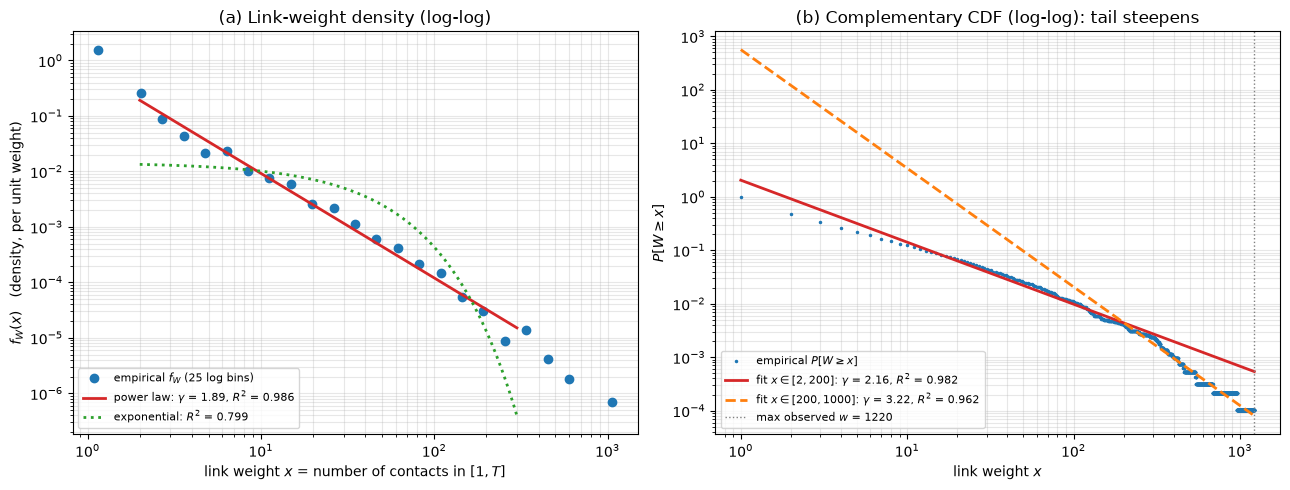

In [87]:
# ---- Q7: distribution of the link weights W (number of contacts per pair) ---
# `edges["w"]` already holds w_ij = total number of contacts between i and j
# inside [1, T], i.e. the L weights of the links of G.
w = edges["w"].to_numpy()
w_max = int(w.max())

# f_W is a probability DENSITY, so each bin count must be divided by both L (to
# turn it into a probability) and by the bin width (to get "per unit weight"):
#     f_W(mid) = (#links in the bin) / (L * bin width),
# which makes sum_k f_W(mid_k) * dx_k = 1. The weights are integers >= 1 that
# span three decades, so logarithmic bins (constant width on a log axis) and
# log-log axes are the insightful choice here.
n_log_bins = 25
bin_edges = np.logspace(0, np.log10(w_max), n_log_bins + 1)    # edge ratio ~1.33
bin_count, _ = np.histogram(w, bins=bin_edges)
bin_width = np.diff(bin_edges)
bin_mid = np.sqrt(bin_edges[:-1] * bin_edges[1:])              # geometric centre
f_W = bin_count / (L * bin_width)                              # density, per unit weight

# The complementary CDF P[W >= x] is smoother than a binned density (no binning
# artefacts), so the power-law exponent is fitted there as well.
x_ccdf_w = np.arange(1, w_max + 1)
ccdf_w = 1 - np.searchsorted(np.sort(w), x_ccdf_w, side="left") / L

def loglog_fit(x, y, lo, hi):
    '''Least-squares slope of log y against log x over lo <= x <= hi (a power law).'''
    m = (x >= lo) & (x <= hi) & (y > 0)
    slope, intercept = np.polyfit(np.log(x[m]), np.log(y[m]), 1)
    logy = np.log(y[m])
    r2 = 1 - np.sum((logy - (slope * np.log(x[m]) + intercept)) ** 2) \
            / np.sum((logy - logy.mean()) ** 2)
    return slope, intercept, r2, int(m.sum())

def loglin_fit(x, y, lo, hi):
    '''Least-squares slope of log y against x over lo <= x <= hi (an exponential).'''
    m = (x >= lo) & (x <= hi) & (y > 0)
    slope, intercept = np.polyfit(x[m], np.log(y[m]), 1)
    logy = np.log(y[m])
    r2 = 1 - np.sum((logy - (slope * x[m] + intercept)) ** 2) \
            / np.sum((logy - logy.mean()) ** 2)
    return slope, intercept, r2, int(m.sum())

# w = 1 is a discreteness spike (a single contact), so the power law is fitted
# over the well-sampled body of the distribution, w in [2, 300].
W_LO, W_HI = 2, 300
s_pow, b_pow, r2_pow, n_pow = loglog_fit(bin_mid, f_W, W_LO, W_HI)
s_exp, b_exp, r2_exp, _ = loglin_fit(bin_mid, f_W, W_LO, W_HI)
gamma_hat = -s_pow

# CCDF fits: a power law P[W >= x] ~ x^-(gamma-1) is a straight line here.
s_c1, b_c1, r2_c1, _ = loglog_fit(x_ccdf_w, ccdf_w, W_LO, 200)    # body
s_c2, b_c2, r2_c2, _ = loglog_fit(x_ccdf_w, ccdf_w, 200, 1000)    # far tail

print(f"L = {L:,} links, weight range {w.min()} .. {w_max}, "
      f"mean {w.mean():.2f}, median {np.median(w):.0f}")
print(f"normalisation  sum_k f_W(mid_k) * dx_k = {(f_W * bin_width).sum():.4f}   (must be 1)")
print(f"sum_ij w_ij = {w.sum():,} = number of contacts in the dataset")
print()
print(f"P[W = 1] = {(w == 1).mean():.3f}   P[W <= 5] = {(w <= 5).mean():.3f}   "
      f"P[W > 100] = {(w > 100).mean():.4f}   P[W > 300] = {(w > 300).mean():.4f}")
print(f"the heaviest 1 % of links carry {np.sort(w)[-int(0.01 * L):].sum() / w.sum():.0%} "
      f"of all contacts")
print()
print(f"power-law fit of the density for w in [{W_LO}, {W_HI}] "
      f"({np.log10(W_HI / W_LO):.2f} decades, {n_pow} bins):")
print(f"  f_W(x) ~ x^-gamma        gamma = {gamma_hat:.2f}   R2 = {r2_pow:.3f}")
print(f"  exponential (same range):            R2 = {r2_exp:.3f}")
print()
print("CCDF fits (power law -> straight line with slope = -(gamma - 1)):")
print(f"  x in [  2, 200]: slope = {s_c1:+.2f}  ->  gamma = {1 - s_c1:.2f}   R2 = {r2_c1:.3f}"
      "   (body)")
print(f"  x in [200,1000]: slope = {s_c2:+.2f}  ->  gamma = {1 - s_c2:.2f}   R2 = {r2_c2:.3f}"
      "   (far tail: steeper -> cut-off)")
print()
print("Maximum-likelihood (Hill) exponent gamma(x_min) = 1 + n / sum log(w_i / x_min);")
print("a pure power law gives the same gamma for every cut-off x_min:")
for x_min in (2, 3, 5, 10, 20, 50):
    tail = w[w >= x_min]
    gamma_hill = 1 + tail.size / np.log(tail / x_min).sum()
    print(f"  x_min = {x_min:3d}   n_tail = {tail.size:5d}   gamma = {gamma_hill:.2f}   "
          f"range = {np.log10(w_max / x_min):.2f} decades")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ok = bin_count > 0
ax[0].loglog(bin_mid[ok], f_W[ok], "o", ms=6, color="C0",
             label=f"empirical $f_W$ ({n_log_bins} log bins)")
xx = np.logspace(np.log10(W_LO), np.log10(W_HI), 100)
ax[0].loglog(xx, np.exp(b_pow) * xx ** s_pow, "-", lw=2, color="C3",
             label=f"power law: $\\gamma$ = {gamma_hat:.2f}, $R^2$ = {r2_pow:.3f}")
ax[0].loglog(xx, np.exp(b_exp + s_exp * xx), ":", lw=2, color="C2",
             label=f"exponential: $R^2$ = {r2_exp:.3f}")
ax[0].set_xlabel("link weight $x$ = number of contacts in $[1,T]$")
ax[0].set_ylabel("$f_W(x)$   (density, per unit weight)")
ax[0].set_title("(a) Link-weight density (log-log)")
ax[0].grid(True, which="both", alpha=0.3)
ax[0].legend(fontsize=8, loc="lower left")

ax[1].loglog(x_ccdf_w, ccdf_w, ".", ms=3, color="C0",
             label="empirical $P[W \\geq x]$")
ax[1].loglog(x_ccdf_w, np.exp(b_c1) * x_ccdf_w ** s_c1, "-", lw=2, color="C3",
             label=f"fit $x\\in[2,200]$: $\\gamma$ = {1 - s_c1:.2f}, $R^2$ = {r2_c1:.3f}")
ax[1].loglog(x_ccdf_w, np.exp(b_c2) * x_ccdf_w ** s_c2, "--", lw=2, color="C1",
             label=f"fit $x\\in[200,1000]$: $\\gamma$ = {1 - s_c2:.2f}, $R^2$ = {r2_c2:.3f}")
ax[1].axvline(w_max, color="grey", ls=":", lw=1, label=f"max observed $w$ = {w_max}")
ax[1].set_xlabel("link weight $x$")
ax[1].set_ylabel("$P[W \\geq x]$")
ax[1].set_title("(b) Complementary CDF (log-log): tail steepens")
ax[1].grid(True, which="both", alpha=0.3)
ax[1].legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()


**Answer — heavy-tailed and closely power-law-like over about two decades, but with a cut-off.**

*The distribution.* The $L = 9510$ links carry integer weights $w_{ij} \in [1, 1220]$ with mean
$7.22$ and median $1$. It is extremely skewed: $51.5\%$ of the links met exactly once and $81.0\%$
met at most five times, while only $23$ links ($0.24\%$) met more than $300$ times; the heaviest
$1\%$ of links carry $31\%$ of all $68{,}679$ contacts. I use $25$ logarithmic bins (edge ratio
$1.33$) and normalise the histogram as a density,
$f_W(\text{mid}) = (\#\text{links in the bin})/(L\,\Delta x)$, so that
$\sum_k f_W(\text{mid}_k)\Delta x_k = 1.0000$ exactly (the code checks this). As a consistency
check, $\sum_{ij} w_{ij} = 68{,}679$ equals the number of rows of the contact list.

*How the power-law question is decided.* A power law $f_W(x)\sim x^{-\gamma}$ is a **straight line on
log–log axes**, whereas an exponential is straight only on log–linear axes; in addition the exponent
must be **stable** when the fitting range changes (Lecture 1 §2.3). I therefore (i) fit the
log-binned density on log–log axes, (ii) fit the smoother complementary CDF $P[W\ge x]$, whose
power-law slope is $-(\gamma-1)$, and (iii) compute the maximum-likelihood (Hill) exponent
$\hat\gamma(x_{\min}) = 1 + n/\sum_i \ln(w_i/x_{\min})$ for a sequence of cut-offs
$x_{\min}$. Ranges, exponents and $R^2$ are printed by the cell.

*Evidence in favour of a power law.* Over the well-sampled body $w \in [2, 300]$ (2.18 decades,
$18$ bins) the density is an almost perfect straight line on log–log axes,
$\hat\gamma = 1.89$ with $R^2 = 0.986$ (over the whole range $w \in [2, 1220]$:
$\hat\gamma = 1.96$, $R^2 = 0.990$). An exponential fitted to the *same* points is decisively worse
($R^2 = 0.799$), so the log–log straightness is not an artefact of the transformation. The CCDF
agrees in the body: $P[W\ge x] \propto x^{-1.16}$, i.e. $\hat\gamma = 2.16$ with $R^2 = 0.982$ for
$x \in [2, 200]$, and the Hill exponent is remarkably stable around $\hat\gamma \approx 2.0$ for
$x_{\min} = 2, 3, 5, 10$ ($1.99, 1.94, 1.96, 2.02$). An exponent close to $2$ is the classical
"scale-free" range: without a cut-off the variance would diverge, which is exactly why the
finite contact budget of the conference matters here.

*Evidence against a pure power law.* Three points, all visible in the figure:

1. **The $w=1$ spike.** More than half of all links ($51.5\%$) sit on the single integer value
   $w=1$, far above any continuous power law — a discreteness effect that also forces the fit to
   start at $w_{\min}=2$.
2. **The tail is not straight.** The CCDF steepens from an exponent $\hat\gamma = 2.16$ in the body
   to $\hat\gamma = 3.22$ for $x \in [200, 1000]$ ($R^2 = 0.962$), and the Hill exponent drifts
   upward as the cut-off moves into the tail ($\hat\gamma = 2.02$ at $x_{\min}=10$, $2.18$ at $20$,
   $2.39$ at $50$). A genuine power law gives a cut-off-independent exponent, so the far tail decays
   *faster than any single power law*.
3. **A finite contact budget.** Only $23$ links exceed $w = 300$ and the largest weight is
   $w_{\max} = 1220 < T = 3259$ (a pair can be in contact at most once per time step, so
   $W \le T$); in that sparse region the binned density is dominated by single-link fluctuations.

**Verdict.** $W$ is **heavy-tailed and very well described by a power law,
$f_W(x) \propto x^{-\hat\gamma}$ with $\hat\gamma \approx 1.9$–$2.0$, over roughly two decades
($w \approx 2$ up to a few hundred)** — a plain exponential is rejected on the same data
($R^2 = 0.80$ versus $0.99$). It is **not, however, a pure scale-free power law** across all scales:
the exponent is not stable (the Hill estimate grows from $\approx 2.0$ to $2.4$, and the CCDF
steepens to $\approx 3.2$ in the far tail) and discreteness produces the dominant $w=1$ spike. The
honest description is therefore a **power law with a cut-off**: a broad algebraic body that
terminates at the finite contact budget of the conference — precisely the "plausibly a power law
over a limited range, with a cut-off" behaviour expected for face-to-face contact data, and the
weighted counterpart of the truncated heavy tail already found for the degree distribution in Q2.


## Part A — summary table of the metrics of $G$

(The assignment recommends collecting all metrics in a table; Q1–Q7 are all here. The weighted
link statistics of Q7 are the last rows of the table.)

In [88]:
# ---- Part A summary ---------------------------------------------------------
part_a_summary = pd.DataFrame(
    [
        ("N", f"{N}", "nodes that ever appear in [1, T]"),
        ("L", f"{L:,}", "unique pairs with at least one contact"),
        ("E[D]", f"{E_D:.2f}", "mean degree = 2L/N"),
        ("p", f"{p_density:.4f}", "link density = L / C(N,2) = <D>/(N-1)"),
        ("Var[D]", f"{Var_D:.2f}", "E[D^2] - E[D]^2"),
        ("sd[D]", f"{sd_D:.2f}", "sqrt(Var[D]); ER/Poisson would give sqrt(<D>) = %.2f" % np.sqrt(E_D)),
        ("d_min, d_max", f"{deg.min()}, {deg.max()}", "degree range (max possible N-1 = 402)"),
        ("Var[D]/E[D]", f"{Var_D / E_D:.2f}", "1 for ER/Poisson -> degrees strongly over-dispersed"),
        ("degree model", "heavy-tailed", "ER rejected (Poisson p(d_max) ~ 1e-42); tail approx. "
                                           "power law alpha ~ 3.7 for k >= 20 but alpha drifts with "
                                           "the fitting range -> truncated power law"),
        ("rho_D", f"{rho_pearson:+.4f}", "degree assortativity (link-end Pearson); weakly disassortative"),
        ("C", f"{C:.4f}", "average local clustering coefficient"),
        ("transitivity", f"{C_transitivity:.4f}", "global clustering, triple-weighted"),
        ("C_ER = p", f"{p_density:.4f}", "ER benchmark; C / C_ER = %.2f" % (C / p_density)),
        ("triangles", f"{int(n_triangles):,}", "number of triangles in G"),
        ("E[H]", f"{E_H:.4f}", f"average hopcount over all {h_pairs.size:,} unordered pairs"),
        ("H_max", f"{H_max}", "diameter (graph is connected)"),
        ("small-world", "yes", f"E[H]/E[H]_ER(G(N,L)) = {E_H / EH_er_null.mean():.2f}, C/C_ER = {C / p_density:.2f}"),
        ("W range", f"{w.min()} .. {w.max()}", "link weight = number of contacts per pair in [1, T]"),
        ("E[W], median W", f"{w.mean():.2f}, {np.median(w):.0f}", f"skewed: {(w == 1).mean():.1%} of the links have W = 1"),
        ("sd[W]", f"{w.std():.2f}", "standard deviation of the link weights"),
        ("heaviest 1% of links", f"{np.sort(w)[-int(0.01 * L):].sum() / w.sum():.0%}", "share of all contacts they carry"),
        ("weight distribution", "power law + cut-off", f"f_W ~ x^-gamma with gamma = {gamma_hat:.2f} for w in [2, 300] (R2 = {r2_pow:.3f}); exponential R2 = {r2_exp:.3f}"),
    ],
    columns=["metric", "value", "definition / remark"],
).set_index("metric")

with pd.option_context("display.max_colwidth", None):
    display(part_a_summary)

,value,definition / remark
metric,,
N,403,"nodes that ever appear in [1, T]"
L,"9,510",unique pairs with at least one contact
E[D],47.20,mean degree = 2L/N
p,0.1174,"link density = L / C(N,2) = <D>/(N-1)"
Var[D],896.71,E[D^2] - E[D]^2
sd[D],29.95,sqrt(Var[D]); ER/Poisson would give sqrt(<D>) = 6.87
"d_min, d_max","1, 168",degree range (max possible N-1 = 402)
Var[D]/E[D],19.00,1 for ER/Poisson -> degrees strongly over-dispersed
degree model,heavy-tailed,ER rejected (Poisson p(d_max) ~ 1e-42); tail approx. power law alpha ~ 3.7 for k >= 20 but alpha drifts with the fitting range -> truncated power law


---

# Part B — Information spreading on the temporal network $G_{data}$

This part uses the temporal graph to simulate an infection spreading process (SI model). There are 3259 timesteps, 403 nodes and the graph captures contact between any 2 nodes if they have contacted during that timestep.

Some points to remember:
- Once infected, a node remains infected.
- When an infected node comes in contact with a susceptible node, the susceptible node becomes infected in that timestep.
- If a node gets infected at t, it cannot infect other nodes until t+1.


## Simulating the information spreading process on the temporal network

The information spreading process is to be simulated for all N nodes. This means 403 simulations, each through the entire timestep. We record $I_s(t)$ = number of infected nodes in the simulation seeded at $s$.  

One way to implement it is to individually consider each of the nodes to be infected and then run through all the links in the correct order. There are about 68679 contacts over all the timestamps. So we would need about 403 × 68,679 ≈ 27.7M contact-checks. 

Instead, we implement a more efficient implementation where we maintain a boolean matrix INF, which keeps track of contact between nodes at each time step (1 if contacted at the timestamp, and 0 if not). The matrix is N * N, and what it keeps track is basically whether node $i$ is infected in the simulation seeded at $s$. We also have $I_t$ of nodes * timesteps to keep track of the number of infected nodes at each timestep in the simulation started at n.


In [89]:
# Load the temporal network G_data 
DATA_FILE_B = "G_data.xlsx"
search_dirs = [Path.cwd()]
nb_file = globals().get("__vsc_ipynb_file__") or globals().get("__file__")
if nb_file:
    search_dirs.insert(0, Path(nb_file).resolve().parent)
for directory in search_dirs:
    candidate = directory / DATA_FILE_B
    if candidate.is_file():
        data_path_B = candidate
        break
else:
    raise FileNotFoundError(f"Could not find {DATA_FILE_B}")

df_B = pd.read_excel(data_path_B)
u_raw = df_B["node1"].to_numpy()
v_raw = df_B["node2"].to_numpy()
t_raw = df_B["timestamp"].to_numpy()

nodes_B = np.union1d(u_raw, v_raw)
N_B = nodes_B.size
node_index_B = pd.Series(np.arange(N_B), index=nodes_B)
ia = node_index_B.loc[u_raw].to_numpy()   
ib = node_index_B.loc[v_raw].to_numpy()   
T = int(t_raw.max())

print(f"N = {N_B} nodes, {len(df_B):,} temporal contacts, T = {T} time steps")
assert N_B == N, "sanity check: same node set as the aggregated network in Part A"


N = 403 nodes, 68,679 temporal contacts, T = 3259 time steps


In [90]:
# simulate SI spreading from every seed simultaneously 
order = np.argsort(t_raw, kind="stable")
t_sorted = t_raw[order]
ia_s, ib_s = ia[order], ib[order]
boundaries = np.searchsorted(t_sorted, np.arange(1, T + 2))
starts = boundaries[:-1]
ends = boundaries[1:]

INF = np.eye(N_B, dtype=bool)
I_t = np.zeros((N_B, T + 1), dtype=np.int32)
I_t[:, 0] = 1

for tt in range(1, T + 1):
    s, e = starts[tt - 1], ends[tt - 1]
    if s != e:
        updates = np.zeros_like(INF)
        for k in range(s, e):
            a, b = ia_s[k], ib_s[k]
            col_a, col_b = INF[:, a], INF[:, b]
            updates[:, b] |= col_a & ~col_b     
            updates[:, a] |= col_b & ~col_a      
        INF |= updates                            
    I_t[:, tt] = INF.sum(axis=1)

# calculate mean, var and SD
E_I = I_t.mean(axis=0)
Var_I = I_t.var(axis=0)
Sd_I = np.sqrt(Var_I)

print(f"E[I(T={T})]  = {E_I[-1]:.2f}   (out of N={N_B})")
print(f"Sd[I(T={T})] = {Sd_I[-1]:.2f}")
print(f"seeds that infect all {N_B} nodes by t=T : {(I_t[:, -1] == N_B).sum()} / {N_B}")
print(f"seeds that do NOT reach everyone by t=T  : {(I_t[:, -1] <  N_B).sum()} / {N_B}"
      f"  (range of final I: {I_t[:, -1].min()} .. {I_t[:, -1].max()})")


E[I(T=3259)]  = 400.12   (out of N=403)
Sd[I(T=3259)] = 5.77
seeds that infect all 403 nodes by t=T : 115 / 403
seeds that do NOT reach everyone by t=T  : 288 / 403  (range of final I: 354 .. 403)


By $t=T=3259$, the average reach across all 403 seeds is $E[I(T)] \approx 400.1$ out of $N=403$. 115 of the 403 seeds infect all 403 nodes.

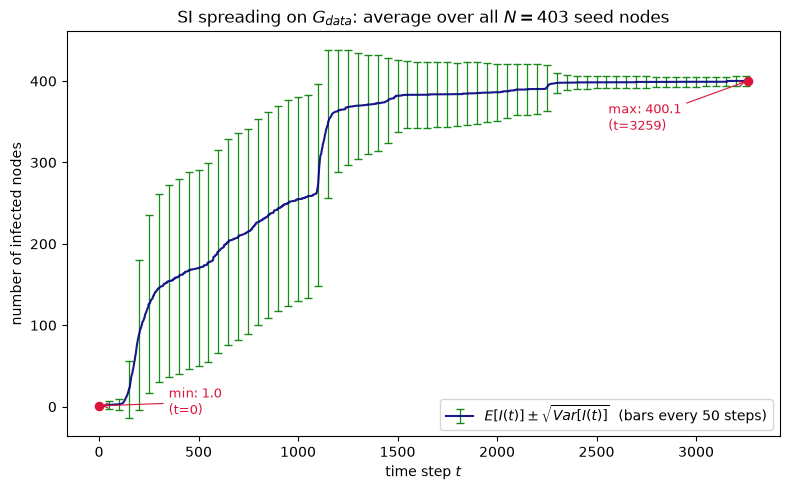

In [91]:
# Q8: plot E[I(t)] with its standard-deviation error band 
fig, ax = plt.subplots(figsize=(8, 5))
tt_axis = np.arange(T + 1)

ax.errorbar(tt_axis, E_I, yerr=Sd_I, errorevery=50, fmt="-", color="navy", lw=1.5,
            capsize=3, elinewidth=0.9, ecolor="green", alpha=0.9,
            label=r"$E[I(t)] \pm \sqrt{Var[I(t)]}$  (bars every 50 steps)")

t_min, t_max = 0, T
y_min, y_max = E_I[t_min], E_I[t_max]

ax.scatter([t_min, t_max], [y_min, y_max], color="crimson", zorder=5, s=35)


ax.annotate(f"min: {y_min:.1f}\n(t={t_min})", xy=(t_min, y_min), xytext=(t_min + 350, y_min - 10),
            fontsize=9, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=0.8))
ax.annotate(f"max: {y_max:.1f}\n(t={t_max})", xy=(t_max, y_max), xytext=(t_max - 700, y_max - 60),
            fontsize=9, color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=0.8))

ax.set_xlabel("time step $t$")
ax.set_ylabel("number of infected nodes")
ax.set_title(r"SI spreading on $G_{data}$: average over all $N=403$ seed nodes")
ax.legend()
fig.tight_layout()
# fig.savefig("q8_spreading.png", dpi=130)
plt.show()

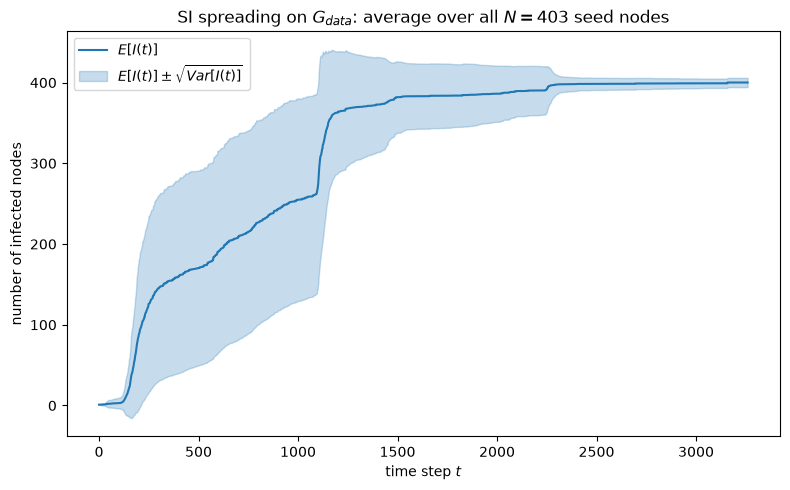

In [92]:
# we also plot a smoother curve to visualise the spread
fig, ax = plt.subplots(figsize=(8, 5))
tt_axis = np.arange(T + 1)
ax.plot(tt_axis, E_I, color="C0", lw=1.5, label=r"$E[I(t)]$")
ax.fill_between(tt_axis, E_I - Sd_I, E_I + Sd_I, color="C0", alpha=0.25,
                 label=r"$E[I(t)] \pm \sqrt{Var[I(t)]}$")
ax.set_xlabel("time step $t$")
ax.set_ylabel("number of infected nodes")
ax.set_title(r"SI spreading on $G_{data}$: average over all $N=403$ seed nodes")
ax.legend()
fig.tight_layout()
# fig.savefig("q8_spreading1.png", dpi=130)
plt.show()


We can see the spread of information visually through the graph shown above. The curve is S-shaped but not smooth. Initially it has a slow start then around t=150, the graph keeps increasing and around t=1100 there is a jump. Finally it flattens into a tail. 

There are sudden bursts in activity in the network, and not a constant rate. 

From the graph, we can see that choice of the initial infected node matters more in the middle phase (around 200-1100) and matters less in the end, where it plateaus and thus there is not much standard deviation. 

## Q9 — Node influence and centrality metric 

The influence of node $i$ is $I_i(t^{(l)}{=}1200)$ - we have this already in the result stored before, we take until (column $t=1200$ of `I_t`, row $i$).

In [93]:
t_l, t_s = 1200, 600
fractions = np.round(np.arange(0.05, 0.51, 0.05), 2)
rng = np.random.default_rng(42)


In [94]:
# Influence metric: I_i(t_l = 1200) for every node as seed 
def compute_metric_influence(I_t, t_target):
    return I_t[:, t_target].astype(float)

influence = compute_metric_influence(I_t, t_l)

n_distinct_infl = np.unique(influence).size
print(f"Influence ranges from, to: {influence.min():.0f} .. {influence.max():.0f}")
print(f"distinct influence values: {n_distinct_infl} / {N_B}  "
      f"-> {N_B - n_distinct_infl} nodes are tied with at least one other node")


Influence ranges from, to: 1 .. 397
distinct influence values: 64 / 403  -> 339 nodes are tied with at least one other node


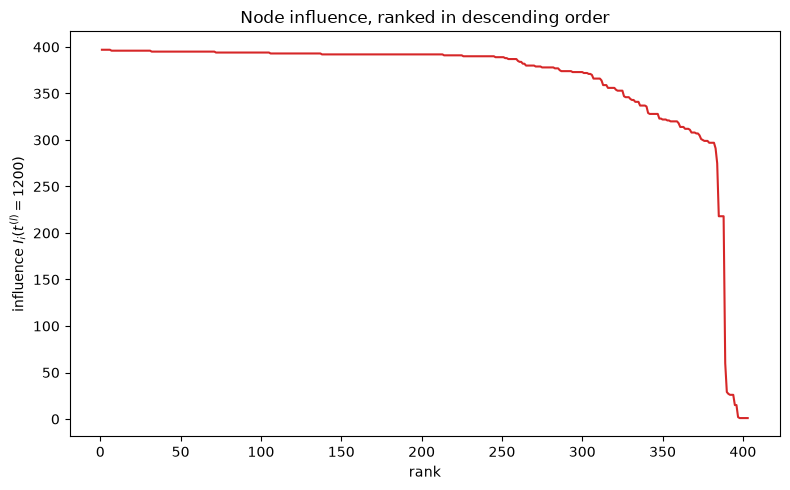

In [95]:
# Plot the influence of every node in descending order
def plot_influence_sorted(influence, title="Node influence, ranked in descending order"):
    order = np.argsort(-influence, kind="stable")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(np.arange(1, influence.size + 1), influence[order], color="C3")
    ax.set_xlabel("rank")
    ax.set_ylabel(r"influence $I_i(t^{(l)}=1200)$")
    ax.set_title(title)
    fig.tight_layout()
    return fig, order

fig2, order_influence = plot_influence_sorted(influence)
# fig2.savefig("q9_2_influence_sorted.png", dpi=130)
plt.show()
R = nodes_B[order_influence]    

In [96]:
# Centrality metric D -  degree in the network aggregated over [1, t_l=1200]
def aggregated_degree(ia, ib, t_raw, max_t, N):
    '''Degree of every node in the network aggregated over [1, max_t].'''
    mask = t_raw <= max_t
    au, av = ia[mask], ib[mask]
    pairs = np.unique(np.stack([np.minimum(au, av), np.maximum(au, av)], axis=1), axis=0)
    d = np.zeros(N, dtype=int)
    np.add.at(d, pairs[:, 0], 1)
    np.add.at(d, pairs[:, 1], 1)
    return d.astype(float)

D = aggregated_degree(ia, ib, t_raw, t_l, N_B)

nd = np.unique(D).size
print(f"D (deg @ t_l=1200): range {D.min():.0f}..{D.max():.0f}, "
      f"{nd} distinct values -> {N_B - nd} nodes tied, {(D == 0).sum()} nodes with 0 contacts by t={t_l}")


D (deg @ t_l=1200): range 0..149, 73 distinct values -> 330 nodes tied, 6 nodes with 0 contacts by t=1200


Below, we compute recognition rate: how much the centrality metric D actually captures node influence R. 

In both sequences (D and R), there would be ties in ranking. For resolving a tie in ranking, we sample the candidates uniformly at random 1000 times to decide which candidate is selected.

Primary and secondary: primary is the node influence metric 
Secondary: metric along with which recognition rate is calculated (we define 3 metrics: degree at t=1200, degree at t=600 and first contact time)

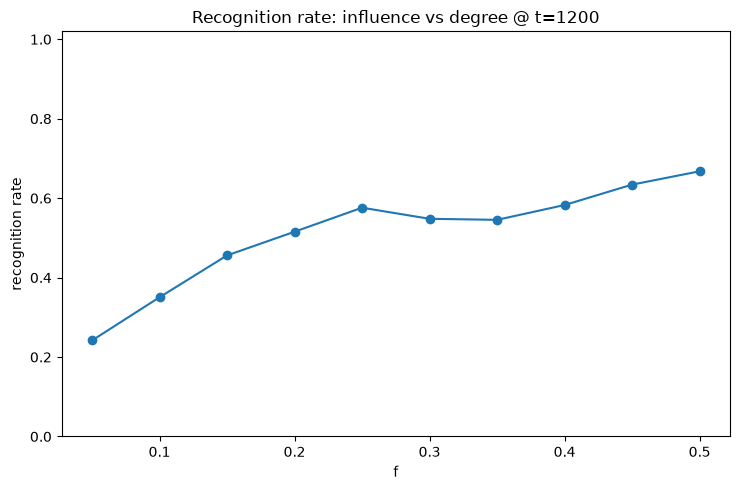

In [97]:
# Recognition rate of influence by D, r_{R,D}(f)
def recognition_curve(primary, secondary, fractions, n_iter=1000, rng=None):
    '''r_{primary,secondary}(f) with randomized tie-breaking, averaged over n_iter draws.
    primary, secondary: bigger value = more central/influential (rank 1 = largest).'''
    if rng is None:
        rng = np.random.default_rng()
    n = primary.size
    totals = np.zeros(len(fractions))
    for _ in range(n_iter):
        r1 = np.lexsort((rng.random(n), -primary))
        r2 = np.lexsort((rng.random(n), -secondary))
        for j, f in enumerate(fractions):
            k = max(int(round(f * n)), 1)
            totals[j] += len(set(r1[:k]) & set(r2[:k])) / k
    return totals / n_iter

def plot_recognition_rates(fractions, curves, title):
    '''curves: list of (label, marker, values) tuples. One tuple -> single-metric plot,
    several tuples -> the combined comparison plot (reused for step 9).'''
    fig, ax = plt.subplots(figsize=(7.5, 5))
    for label, marker, values in curves:
        ax.plot(fractions, values, marker + "-", label=label)
    ax.set_xlabel("f")
    ax.set_ylabel("recognition rate")
    ax.set_ylim(0, 1.02)
    ax.set_title(title)
    if len(curves) > 1:
        ax.legend()
    fig.tight_layout()
    return fig

rRD = recognition_curve(influence, D, fractions, n_iter=1000, rng=rng)
fig4 = plot_recognition_rates(fractions, [(r"$r_{R,D}(f)$ (deg @ t=1200)", "o", rRD)],
                               "Recognition rate: influence vs degree @ t=1200")
# fig4.savefig("q9_4_rRD.png", dpi=130)
plt.show()


Now we need to compute the second centrality metric D', which is the degree of each node in the network formed by aggregating the network until $t^s$ = 600. In case of ties, we sample the candidates uniformly at random 1000 times to decide which candidate is selected.

In [98]:
# Metric D': degree in the network aggregated over [1, t_s=600]
Dp = aggregated_degree(ia, ib, t_raw, t_s, N_B)

nd = np.unique(Dp).size
print(f"D' (deg @ t_s=600): range {Dp.min():.0f}..{Dp.max():.0f}, "
      f"{nd} distinct values -> {N_B - nd} nodes tied, {(Dp == 0).sum()} nodes with 0 contacts by t_s")


D' (deg @ t_s=600): range 0..87, 47 distinct values -> 356 nodes tied, 99 nodes with 0 contacts by t_s


Similar to the previous part, we now calculate recognition rate of influence by D' , $r_{R,D'}$($f$) for $f$ = 0.05,0.1,...0.5

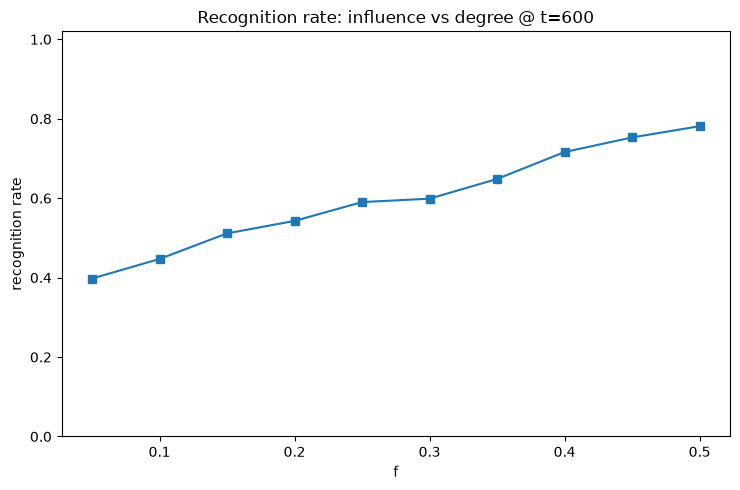

In [99]:
# Recognition rate of influence by D', r_{R,D'}(f)
rRDp = recognition_curve(influence, Dp, fractions, n_iter=1000, rng=rng)
fig6 = plot_recognition_rates(fractions, [(r"$r_{R,D'}(f)$ (deg @ t=600)", "s", rRDp)],
                               "Recognition rate: influence vs degree @ t=600")
# fig6.savefig("q9_6_rRDp.png", dpi=130)
plt.show()


In [100]:
# metric Z: first-contact time of every node
def first_contact_time(ia, ib, t_raw, N):
    Z = np.full(N, np.inf)
    np.minimum.at(Z, ia, t_raw)
    np.minimum.at(Z, ib, t_raw)
    return Z

Z = first_contact_time(ia, ib, t_raw, N_B)

nd = np.unique(Z).size
print(f"Z (first contact): range {Z.min():.0f}..{Z.max():.0f}, "
      f"{nd} distinct values -> {N_B - nd} nodes tied")


Z (first contact): range 1..2257, 217 distinct values -> 186 nodes tied


The value of z ranges from 1 to 2257. There are only 217 distinct values. Like the previous case, for resolving a tie in ranking, we sample the candidates uniformly at random 1000 times to decide which candidate is selected.

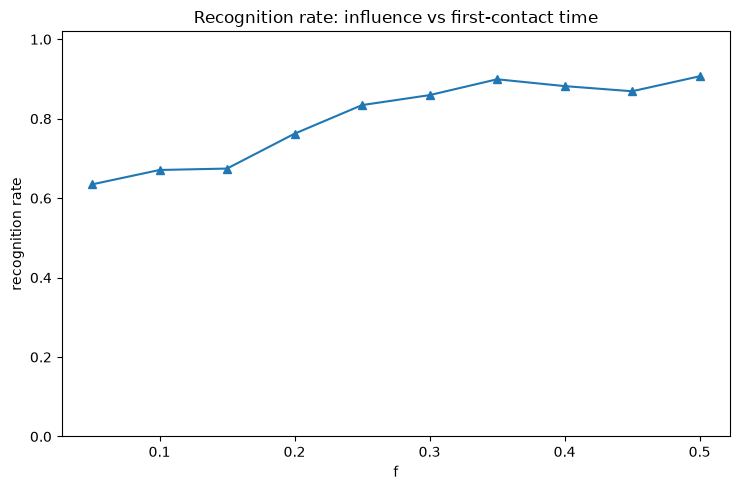

In [101]:
# Recognition rate of influence by Z, r_{R,Z}(f)
# smaller Z => earlier first contact
rRZ = recognition_curve(influence, -Z, fractions, n_iter=1000, rng=rng)
fig8 = plot_recognition_rates(fractions, [(r"$r_{R,Z}(f)$ (first contact)", "^", rRZ)],
                               "Recognition rate: influence vs first-contact time")
# fig8.savefig("q9_8_rRZ.png", dpi=130)
plt.show()


The three metrics are shown in the table and graph below to help in comparing which one more resembles $R_f$

,"r_R,D (deg@1200)","r_R,D' (deg@600)","r_R,Z (1st contact)"
f,,,
0.05,0.242,0.398,0.635
0.10,0.350,0.447,0.671
0.15,0.456,0.511,0.675
0.20,0.516,0.543,0.762
0.25,0.576,0.590,0.834
0.30,0.548,0.599,0.859
0.35,0.545,0.648,0.899
0.40,0.583,0.716,0.882
0.45,0.634,0.753,0.869


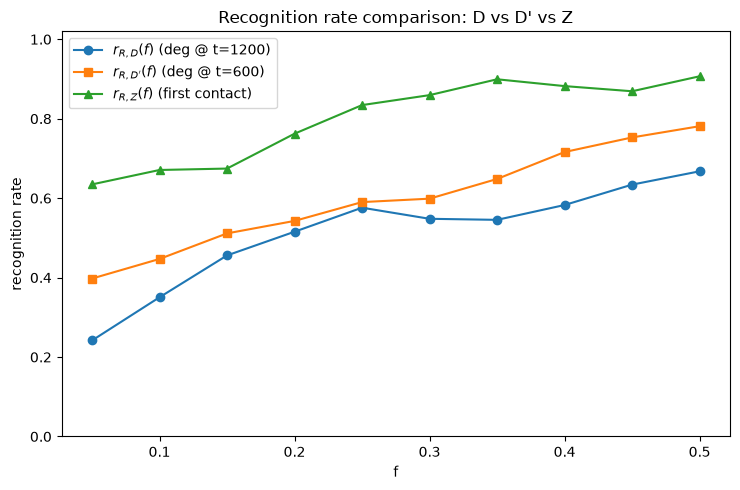

In [102]:
# rRD(f), rRD'(f), rRZ(f) together for direct comparison
results = pd.DataFrame({"f": fractions, "r_R,D (deg@1200)": rRD,
                         "r_R,D' (deg@600)": rRDp, "r_R,Z (1st contact)": rRZ}).set_index("f")
display(results.round(3))

fig9 = plot_recognition_rates(fractions,
    [(r"$r_{R,D}(f)$ (deg @ t=1200)", "o", rRD),
     (r"$r_{R,D'}(f)$ (deg @ t=600)", "s", rRDp),
     (r"$r_{R,Z}(f)$ (first contact)", "^", rRZ)],
    "Recognition rate comparison: D vs D' vs Z")
# fig9.savefig("q9_9_combined.png", dpi=130)
plt.show()
